In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df=pd.read_csv(r'C:\Users\Lenovo\OneDrive\Desktop\practice\Dataset19-Housing_Price_data.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [70]:
df.shape

(545, 13)

In [71]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [73]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [74]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [75]:
cat_col=df.select_dtypes(include='object').columns.tolist()
cat_col

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [76]:
num_col=df.select_dtypes(include='number').columns.tolist()
num_col

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

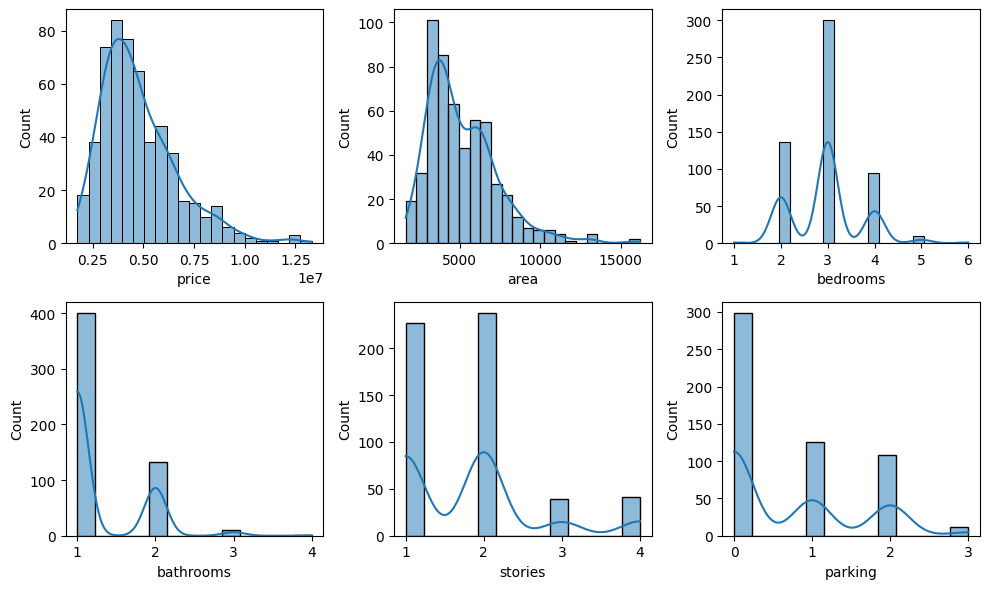

In [77]:
plt.figure(figsize=(10,6))
for index,column in enumerate(num_col):
    plt.subplot(2,3,index+1)
    sns.histplot(df[column],kde=True)
    plt.tight_layout()

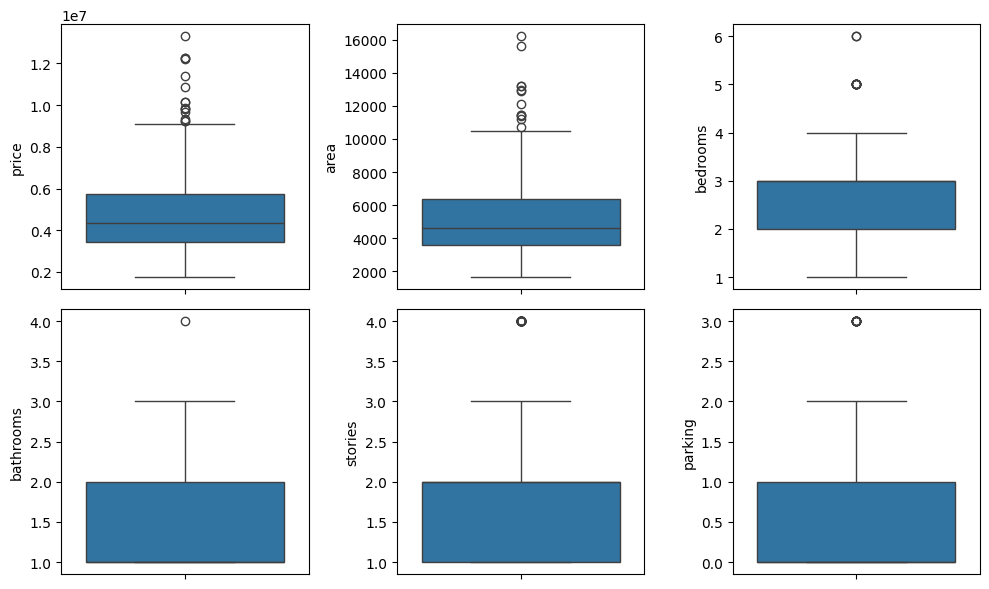

In [78]:
plt.figure(figsize=(10,6))
for index,column in enumerate(num_col):
    plt.subplot(2,3,index+1)
    sns.boxplot(df[column])
    plt.tight_layout()

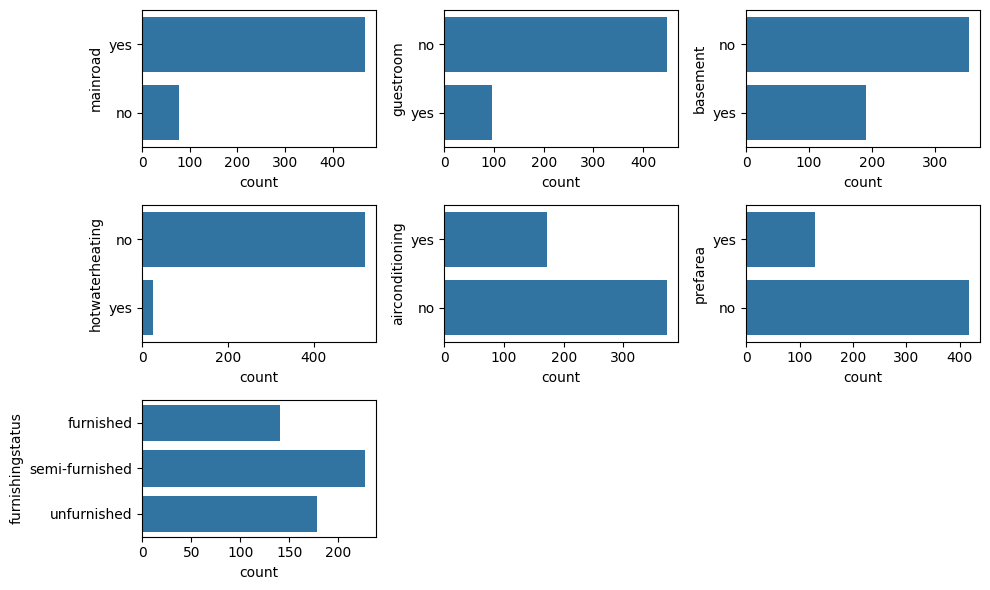

In [79]:
plt.figure(figsize=(10,6))
for index,column in enumerate(cat_col):
    plt.subplot(3,3,index+1)
    sns.countplot(df[column])
    plt.tight_layout()

In [80]:
df = pd.get_dummies(df, columns=cat_col, drop_first=True)
df=df.astype(int)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


KeyError: 'furnishingstatus'

<Axes: >

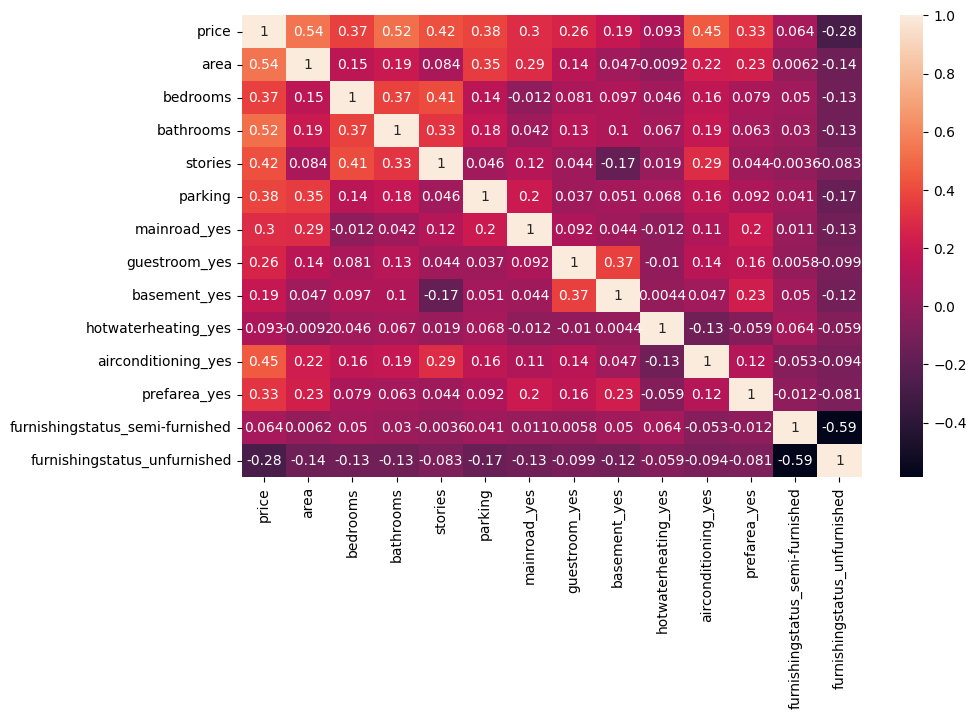

In [82]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

In [83]:
df.corr()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394,0.296898,0.255517,0.187057,0.093073,0.452954,0.329777,0.063656,-0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980,0.288874,0.140297,0.047417,-0.009229,0.222393,0.234779,0.006156,-0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270,-0.012033,0.080549,0.097312,0.046049,0.160603,0.079023,0.050040,-0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496,0.042398,0.126469,0.102106,0.067159,0.186915,0.063472,0.029834,-0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547,0.121706,0.043538,-0.172394,0.018847,0.293602,0.044425,-0.003648,-0.082972
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000,0.204433,0.037466,0.051497,0.067864,0.159173,0.091627,0.041327,-0.165705
mainroad_yes,0.296898,0.288874,-0.012033,0.042398,0.121706,0.204433,1.000000,0.092337,0.044002,-0.011781,0.105423,0.199876,0.011450,-0.133123
guestroom_yes,0.255517,0.140297,0.080549,0.126469,0.043538,0.037466,0.092337,1.000000,0.372066,-0.010308,0.138179,0.160897,0.005821,-0.099023
basement_yes,0.187057,0.047417,0.097312,0.102106,-0.172394,0.051497,0.044002,0.372066,1.000000,0.004385,0.047341,0.228083,0.050284,-0.117935
hotwaterheating_yes,0.093073,-0.009229,0.046049,0.067159,0.018847,0.067864,-0.011781,-0.010308,0.004385,1.000000,-0.130023,-0.059411,0.063819,-0.059194


In [185]:
x=df.drop('price',axis=1)
y=df['price']

In [186]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [187]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))   # only transform

In [188]:
x_train.shape

(436, 13)

In [189]:
from tensorflow import keras
from keras.layers import Dense,Dropout
from keras.models import Sequential


In [210]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=13))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='linear'))

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [211]:
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

In [212]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['r2_score'])

In [ ]:
history=model.fit(x_train_scaled,y_train,batsch_size=32,epochs=100,validation_data=(x_test_scaled,y_test_scaled))

Epoch 1/100


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 25234788843520.0000 - r2_score: -7.1841 - val_loss: 1.5442 - val_r2_score: 0.0580
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25234782552064.0000 - r2_score: -7.1841 - val_loss: 3.7854 - val_r2_score: -1.3092
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25234763677696.0000 - r2_score: -7.1841 - val_loss: 32.3714 - val_r2_score: -18.7472
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25234690277376.0000 - r2_score: -7.1841 - val_loss: 307.8661 - val_r2_score: -186.8047
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25234499436544.0000 - r2_score: -7.1840 - val_loss: 2423.2139 - val_r2_score: -1477.2106
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25234004508672.0000 - r2_score: -7.1839 - val_loss: 16298.1738 - val_r2_score: -9941.2236
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25232790257664.0000 - r2_score: -7.1835 - val_loss: 94815.5703 - val_r2_score: -57

In [199]:
print(x_train_scaled.shape)
print(y_train.shape)

(436, 13)
(436,)


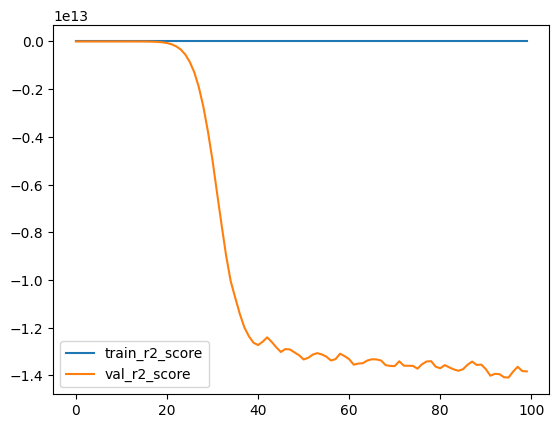

In [215]:
plt.plot(history.history['r2_score'],label='train_r2_score')
plt.plot(history.history['val_r2_score'],label='val_r2_score') 
plt.legend() 

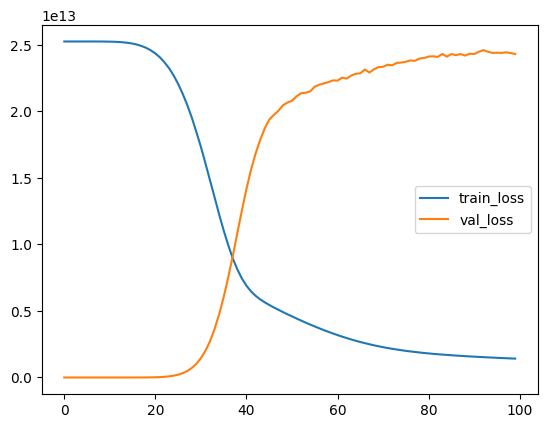

In [201]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss') 
plt.legend() 

In [218]:
model.evaluate(x_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 16543850085843206144.0000 - r2_score: -3273046.7500 


[1.6543850085843206e+19, -3273046.75]

In [150]:
y_test_scaled

array([[-0.36819046],
       [ 1.10678695],
       [-0.56751173],
       [ 0.98719418],
       [-1.08574703],
       [ 0.11018059],
       [ 0.30950186],
       [-0.0931271 ],
       [-1.2850683 ],
       [-0.77081942],
       [ 3.09999965],
       [-1.16547554],
       [-0.766833  ],
       [-0.766833  ],
       [-1.38472894],
       [-1.16547554],
       [-1.16547554],
       [ 1.50542949],
       [-1.00601852],
       [-1.04588278],
       [ 1.1466512 ],
       [ 0.4091625 ],
       [-1.60398234],
       [ 0.30950186],
       [-0.29244837],
       [ 4.29592728],
       [-0.92629001],
       [ 0.22977335],
       [ 2.90067838],
       [-1.24520405],
       [ 1.18651545],
       [-0.68710449],
       [ 1.10678695],
       [-1.00601852],
       [-0.78676513],
       [-0.28846195],
       [ 0.11018059],
       [-0.80669725],
       [-0.68710449],
       [-1.32493256],
       [ 0.44902675],
       [-0.58744385],
       [ 1.10678695],
       [ 0.11416702],
       [-0.88642576],
       [-0

In [206]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(x_train_scaled,y_train_scaled.ravel())
rf.score(x_test_scaled,y_test_scaled)


0.6210425038592775

In [216]:
from xgboost import XGBRegressor
rf=XGBRegressor()
rf.fit(x_train_scaled,y_train_scaled.ravel())
rf.score(x_test_scaled,y_test_scaled)


0.5857734668319035